First few rows of data:
   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
0             1  2010-06-04       Falcon 9  6104.959412   LEO  CCAFS SLC 40   
1             2  2012-05-22       Falcon 9   525.000000   LEO  CCAFS SLC 40   
2             3  2013-03-01       Falcon 9   677.000000   ISS  CCAFS SLC 40   
3             4  2013-09-29       Falcon 9   500.000000    PO   VAFB SLC 4E   
4             5  2013-12-03       Falcon 9  3170.000000   GTO  CCAFS SLC 40   

       Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  \
0    None None        1     False   False  False        NaN    1.0   
1    None None        1     False   False  False        NaN    1.0   
2    None None        1     False   False  False        NaN    1.0   
3  False Ocean        1     False   False  False        NaN    1.0   
4    None None        1     False   False  False        NaN    1.0   

   ReusedCount Serial   Longitude   Latitude  Class  
0            0  B0003  -80

/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it


=== LOGISTIC REGRESSION ===
Tuned hyperparameters (best parameters): {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation accuracy: 0.8464
Logistic Regression - Test Accuracy: 0.8333


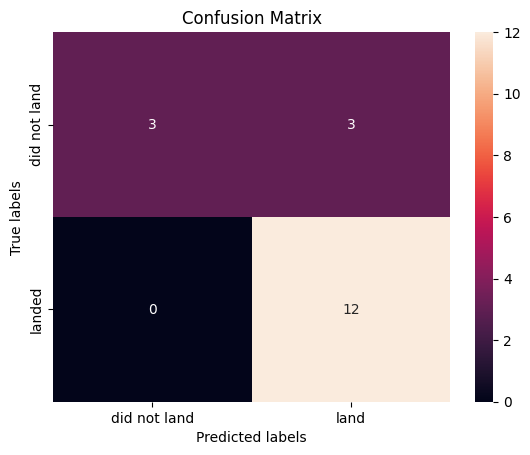


=== SUPPORT VECTOR MACHINE ===
Tuned hyperparameters (best parameters): {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
Best cross-validation accuracy: 0.8482
SVM - Test Accuracy: 0.8333


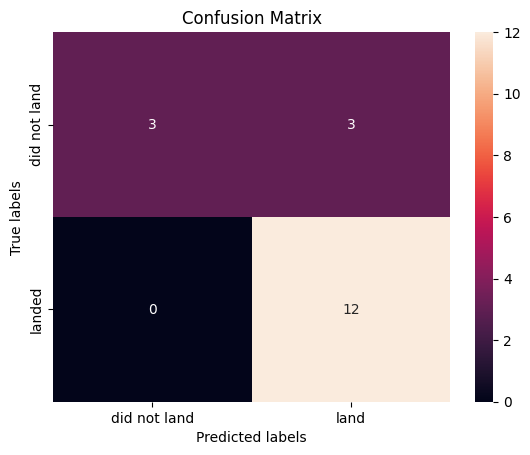


=== DECISION TREE ===
Tuned hyperparameters (best parameters): {'criterion': 'entropy', 'max_depth': 18, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'random'}
Best cross-validation accuracy: 0.8768
Decision Tree - Test Accuracy: 0.9444


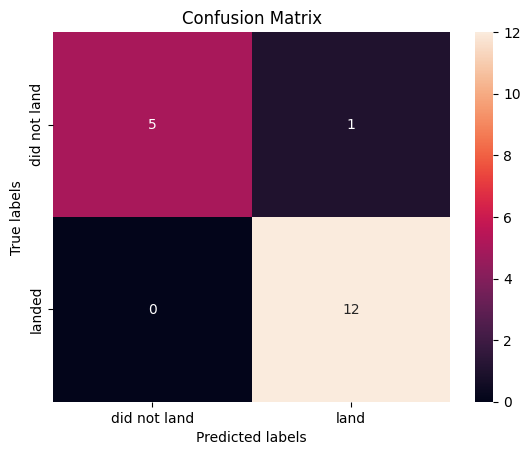


=== k-NEAREST NEIGHBORS ===
Tuned hyperparameters (best parameters): {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
Best cross-validation accuracy: 0.8482
kNN - Test Accuracy: 0.8333


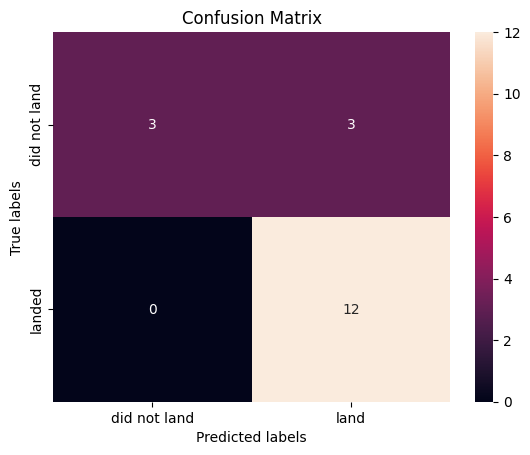


FINAL MODEL COMPARISON - TEST ACCURACY
Logistic Regression  : 0.8333
SVM                  : 0.8333
Decision Tree        : 0.9444
k-Nearest Neighbors  : 0.8333
------------------------------------------------------------
→ BEST PERFORMING MODEL: Decision Tree
   Test accuracy: 0.9444

Note: Results may vary slightly depending on random_state and dataset version.
      SVM is often the top performer on this particular SpaceX dataset.


In [2]:
# Space X  Falcon 9 First Stage Landing Prediction
## Hands-on Lab: Complete the Machine Learning Prediction lab

# Import Libraries and Define Auxiliary Functions

!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


def plot_confusion_matrix(y, y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax=ax)  # annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix')
    ax.xaxis.set_ticklabels(['did not land', 'land'])
    ax.yaxis.set_ticklabels(['did not land', 'landed'])
    plt.show()


# Load the dataframe

# Dataset 1 - flight data + class
URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
data = pd.read_csv(URL1)

# Dataset 2 - features (already one-hot encoded + standardized in some versions)
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
X = pd.read_csv(URL2)

print("First few rows of data:")
print(data.head())
print("\nFirst few rows of features X:")
print(X.head())

# TASK 1
# Create a NumPy array from the column 'Class' in data
Y = data['Class'].to_numpy()
# Y is now a 1D numpy array containing 0s and 1s

print("Shape of target Y:", Y.shape)
print("First 10 values:", Y[:10])

# TASK 2
# Standardize the data in X
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

print("Features X after standardization (shape):", X.shape)

# TASK 3
# Split into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=2
)

print("Training set shape:", X_train.shape, Y_train.shape)
print("Test set shape:    ", X_test.shape, Y_test.shape)
print("Number of test samples:", Y_test.shape[0])

# TASK 4 - Logistic Regression + GridSearchCV

parameters = {
    'C': [0.01, 0.1, 1],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

lr = LogisticRegression(max_iter=1000)

logreg_cv = GridSearchCV(
    estimator=lr,
    param_grid=parameters,
    cv=10,
    scoring='accuracy'
)

logreg_cv.fit(X_train, Y_train)

print("\n=== LOGISTIC REGRESSION ===")
print("Tuned hyperparameters (best parameters):", logreg_cv.best_params_)
print("Best cross-validation accuracy:", round(logreg_cv.best_score_, 4))

# TASK 5 - Accuracy on test data
logreg_score = logreg_cv.score(X_test, Y_test)
print("Logistic Regression - Test Accuracy:", round(logreg_score, 4))

# Confusion Matrix
yhat_lr = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat_lr)

# TASK 6 - Support Vector Machine

parameters = {
    'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
    'C': np.logspace(-3, 3, 5),
    'gamma': np.logspace(-3, 3, 5)
}

svm = SVC()

svm_cv = GridSearchCV(
    estimator=svm,
    param_grid=parameters,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

svm_cv.fit(X_train, Y_train)

print("\n=== SUPPORT VECTOR MACHINE ===")
print("Tuned hyperparameters (best parameters):", svm_cv.best_params_)
print("Best cross-validation accuracy:", round(svm_cv.best_score_, 4))

# TASK 7
svm_score = svm_cv.score(X_test, Y_test)
print("SVM - Test Accuracy:", round(svm_score, 4))

yhat_svm = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat_svm)

# TASK 8 - Decision Tree

parameters = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2*n for n in range(1, 10)],
    'max_features': ['sqrt', 'log2'],          # 'auto' deprecated
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

tree = DecisionTreeClassifier()

tree_cv = GridSearchCV(
    estimator=tree,
    param_grid=parameters,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

tree_cv.fit(X_train, Y_train)

print("\n=== DECISION TREE ===")
print("Tuned hyperparameters (best parameters):", tree_cv.best_params_)
print("Best cross-validation accuracy:", round(tree_cv.best_score_, 4))

# TASK 9
tree_score = tree_cv.score(X_test, Y_test)
print("Decision Tree - Test Accuracy:", round(tree_score, 4))

yhat_tree = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat_tree)

# TASK 10 - k-Nearest Neighbors

parameters = {
    'n_neighbors': list(range(1, 11)),
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}

KNN = KNeighborsClassifier()

knn_cv = GridSearchCV(
    estimator=KNN,
    param_grid=parameters,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

knn_cv.fit(X_train, Y_train)

print("\n=== k-NEAREST NEIGHBORS ===")
print("Tuned hyperparameters (best parameters):", knn_cv.best_params_)
print("Best cross-validation accuracy:", round(knn_cv.best_score_, 4))

# TASK 11
knn_score = knn_cv.score(X_test, Y_test)
print("kNN - Test Accuracy:", round(knn_score, 4))

yhat_knn = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat_knn)

# TASK 12 - Which method performs best?

print("\n" + "="*60)
print("FINAL MODEL COMPARISON - TEST ACCURACY")
print("="*60)

results = {
    "Logistic Regression": logreg_score,
    "SVM":                 svm_score,
    "Decision Tree":       tree_score,
    "k-Nearest Neighbors": knn_score
}

for model, acc in results.items():
    print(f"{model:20} : {acc:.4f}")

best_model = max(results, key=results.get)
print("-"*60)
print(f"→ BEST PERFORMING MODEL: {best_model}")
print(f"   Test accuracy: {results[best_model]:.4f}")
print("="*60)

print("\nNote: Results may vary slightly depending on random_state and dataset version.")
print("      SVM is often the top performer on this particular SpaceX dataset.")



In [3]:
print('')